# Applying functions to Dataframes
# pandas.DataFrame.apply
#### We can apply functions to all the values in a single column or all the values in a single row.

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [71]:
titanic = pd.read_csv('../../../data/titanic.csv')

In [72]:
titanic['age'] = titanic['age'].replace(['?'], [None]).astype('float')
titanic['fare'] = titanic['fare'].replace(['?'], [None]).astype('float')

In [73]:
titanic_df = titanic[['pclass', 'survived', 'age', 'fare']]

In [74]:
titanic_df

,pclass,survived,age,fare
0,1,1,29.0000,211.3375
1,1,1,0.9167,151.5500
2,1,0,2.0000,151.5500
3,1,0,30.0000,151.5500
4,1,0,25.0000,151.5500
...,...,...,...,...
1304,3,0,14.5000,14.4542
1305,3,0,NaN,14.4542
1306,3,0,26.5000,7.2250
1307,3,0,27.0000,7.2250


# Columns
## In case we do not define the axis in the apply() then it is going to apply the function to all the columns in the dataframe (axis = 0) by default

#### Let us write a function that gives the (max - min) of a series

In [75]:
def get_range(x):
    return x.max() - x.min()

In [76]:
titanic_df.apply(get_range)

pclass        2.0000
survived      1.0000
age          79.8333
fare        512.3292
dtype: float64

# Rows
## axis = 1

In [77]:
titanic_df.apply(get_range, axis=1)

0       210.3375
1       150.6333
2       151.5500
3       151.5500
4       151.5500
          ...   
1304     14.5000
1305     14.4542
1306     26.5000
1307     27.0000
1308     29.0000
Length: 1309, dtype: float64

In [78]:
def get_fam_size(x):
    fam_size = x.sibsp + x.parch
    if fam_size == 0:
        return 'solo'
    elif fam_size < 5:
        return 'average'
    else:
        return 'large'

In [79]:
titanic.apply(get_fam_size, axis = 1)

0          solo
1       average
2       average
3       average
4       average
         ...   
1304    average
1305    average
1306       solo
1307       solo
1308       solo
Length: 1309, dtype: object

In [80]:
titanic['fam_size'] = titanic.apply(get_fam_size, axis = 1)

In [81]:
titanic

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,fam_size
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO",solo
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON",average
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON",average
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON",average
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON",average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,?,C,?,328,?,average
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,?,C,?,?,?,average
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,?,C,?,304,?,solo
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,?,C,?,?,?,solo


<Axes: xlabel='fam_size'>

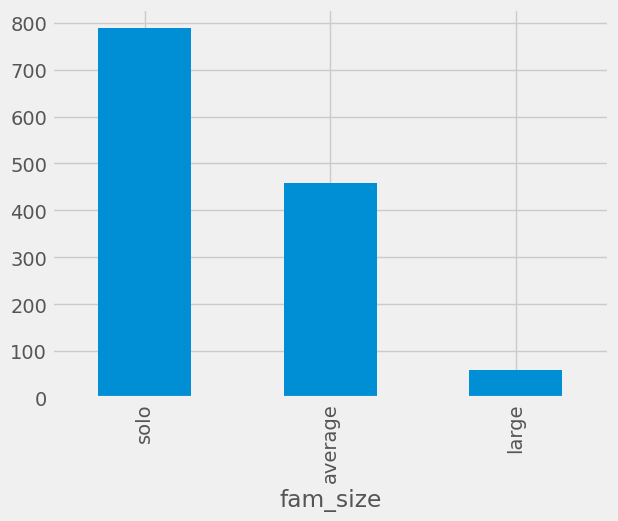

In [82]:
titanic['fam_size'].value_counts().sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='fam_size'>

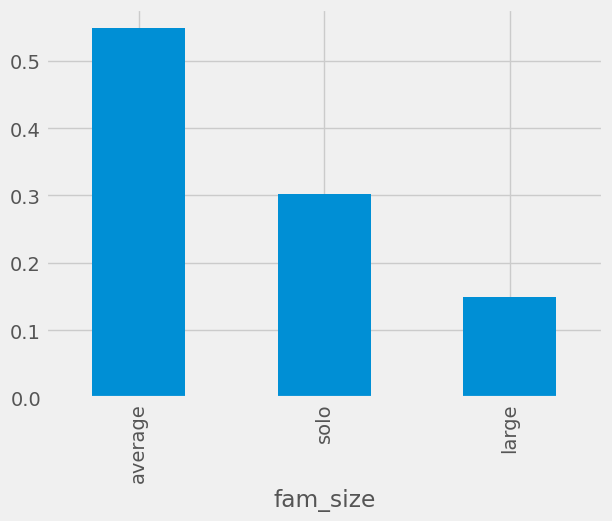

In [86]:
titanic.groupby('fam_size').survived.mean().sort_values(ascending=False).plot(kind='bar')